In [2]:
import os

import torch
from torch.utils.data import DataLoader
from datasets import load_from_disk

from src.dataset import ATRClothesDataset
from src.transforms import get_train_transforms, get_val_transforms
from src.model import UNetResNet34
from src.losses import BCEDiceLoss
from src.metrics import get_metrics, update_metrics, compute_metrics, reset_metrics


In [6]:
BATCH_SIZE = 8
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

TRAIN_PATH = r"data/Images/train"
VAL_PATH = r"data/Images/val"

CHECKPOINT_DIR = r"outputs/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Device:", DEVICE)

Device: cuda


In [7]:
TRAIN_PATH = r"data/Images/train"
VAL_PATH = r"data/Images/val"

In [8]:
print("Loading dataset...")

train_split = load_from_disk(TRAIN_PATH)
val_split = load_from_disk(VAL_PATH)

train_dataset = ATRClothesDataset(
    train_split,
    transform=get_train_transforms()
)

val_dataset = ATRClothesDataset(
    val_split,
    transform=get_val_transforms()
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Loading dataset...
Train samples: 12394
Val samples: 2656


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 1550
Val batches: 332


In [10]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

Images shape: torch.Size([8, 3, 256, 256])
Masks shape: torch.Size([8, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.uint8


In [11]:
model = UNetResNet34(
    pretrained=True
)

model = model.to(DEVICE)

print(model.__class__.__name__)

UNetResNet34


In [12]:
criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [13]:
train_metrics = get_metrics(DEVICE)
val_metrics = get_metrics(DEVICE)

best_val_dice = 0.0

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, metrics):
    model.train()

    total_loss = 0.0
    reset_metrics(metrics)

    for images, masks in loader:

        images = images.to(DEVICE)
        masks = masks.float().unsqueeze(1).to(DEVICE)

        logits = model(images)

        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        update_metrics(
            metrics,
            logits.detach(),
            masks
        )

    avg_loss = total_loss / len(loader)

    results = compute_metrics(metrics)

    return avg_loss, results

In [15]:
def validate(model, loader, criterion, metrics):

    model.eval()

    total_loss = 0.0
    reset_metrics(metrics)

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(DEVICE)
            masks = masks.float().unsqueeze(1).to(DEVICE)

            logits = model(images)

            loss = criterion(logits, masks)

            total_loss += loss.item()

            update_metrics(
                metrics,
                logits,
                masks
            )

    avg_loss = total_loss / len(loader)

    results = compute_metrics(metrics)

    return avg_loss, results

In [16]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "lr": []
}

In [17]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_results = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        train_metrics
    )

    val_loss, val_results = validate(
        model,
        val_loader,
        criterion,
        val_metrics
    )

    scheduler.step(val_results["dice"])

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_results["dice"])
    history["val_dice"].append(val_results["dice"])

    history["train_iou"].append(train_results["iou"])
    history["val_iou"].append(val_results["iou"])

    history["val_precision"].append(
        val_results["precision"]
    )

    history["val_recall"].append(
        val_results["recall"]
    )

    history["lr"].append(
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Dice: {train_results['dice']:.4f} | "
        f"Train IoU: {train_results['iou']:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_results['dice']:.4f} | "
        f"Val IoU: {val_results['iou']:.4f}"
    )

    print(
        f"Val Precision: {val_results['precision']:.4f} | "
        f"Val Recall: {val_results['recall']:.4f}"
    )

    print(
        f"Learning Rate: "
        f"{optimizer.param_groups[0]['lr']:.6f}"
    )

    # Save best model
    if val_results["dice"] > best_val_dice:

        best_val_dice = val_results["dice"]

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            "best_model.pth"
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": best_val_dice,
            },
            checkpoint_path
        )

        print(
            f"✓ Best model saved: {checkpoint_path}"
        )

    print("-" * 60)


Epoch [1/20]
Train Loss: 0.2266 | Train Dice: 0.8945 | Train IoU: 0.8092
Val Loss: 0.1214 | Val Dice: 0.9253 | Val IoU: 0.8610
Val Precision: 0.9327 | Val Recall: 0.9181
Learning Rate: 0.000100
✓ Best model saved: outputs/checkpoints\best_model.pth
------------------------------------------------------------

Epoch [2/20]
Train Loss: 0.0948 | Train Dice: 0.9286 | Train IoU: 0.8667
Val Loss: 0.0793 | Val Dice: 0.9332 | Val IoU: 0.8747
Val Precision: 0.9312 | Val Recall: 0.9352
Learning Rate: 0.000100
✓ Best model saved: outputs/checkpoints\best_model.pth
------------------------------------------------------------

Epoch [3/20]
Train Loss: 0.0740 | Train Dice: 0.9357 | Train IoU: 0.8792
Val Loss: 0.0743 | Val Dice: 0.9335 | Val IoU: 0.8753
Val Precision: 0.9349 | Val Recall: 0.9321
Learning Rate: 0.000100
✓ Best model saved: outputs/checkpoints\best_model.pth
------------------------------------------------------------

Epoch [4/20]
Train Loss: 0.0661 | Train Dice: 0.9403 | Train IoU: 

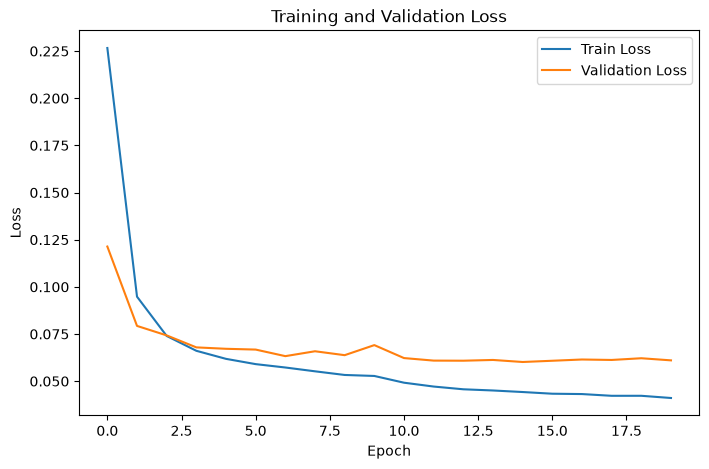

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

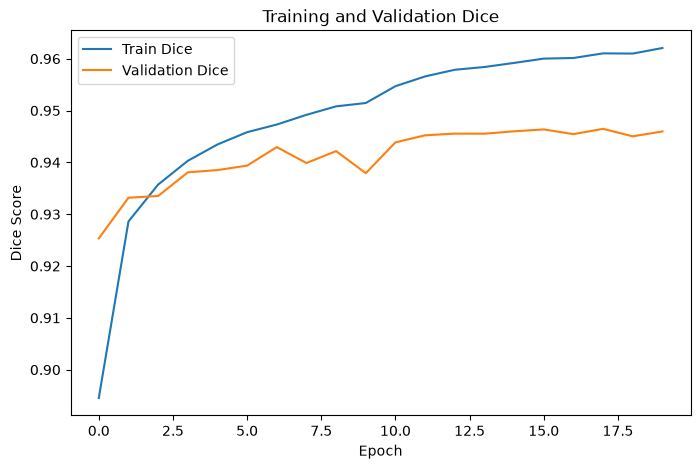

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_dice"],
    label="Train Dice"
)

plt.plot(
    history["val_dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice")
plt.legend()
plt.show()

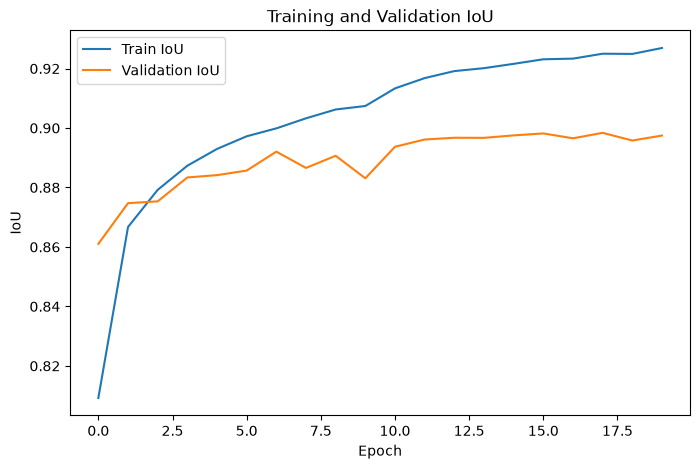

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU")
plt.legend()
plt.show()